# Retention Strategy Simulation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

RANDOM_STATE = 42

In [3]:
df = pd.read_csv('../data/Bank Customer Churn Prediction.csv')
df.columns = df.columns.str.lower()
df = df.drop(columns=['customer_id', 'surname'], errors='ignore')

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=RANDOM_STATE
)

final_model = CatBoostClassifier(
    depth=5, 
    iterations=200,
    l2_leaf_reg=9,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    verbose=0
)
final_model.fit(X_train, y_train)

CatBoostClassifier(depth=5, iterations=200, l2_leaf_reg=9, learning_rate=0.05, random_state=42, verbose=0)

### Scoring, Ranking, and Segmenting Clients into Deciles

In [6]:
probabilities = final_model.predict_proba(X_test)[:, 1]

sim_df = pd.DataFrame({
    'actual_churn': y_test.values,
    'churn_prob': probabilities,
    'balance': X_test['balance'].values
})
sim_df = sim_df.sort_values(by='churn_prob', ascending=False).reset_index(drop=True)
sim_df['decile'] = pd.qcut(
    sim_df['churn_prob'].rank(method='first'), 
    q=10, 
    labels=np.arange(1, 11)[::-1]
)

decile_summary = sim_df.groupby('decile', observed=False).agg(
    total_customers=('actual_churn', 'count'),
    actual_churners=('actual_churn', 'sum'),
    total_balance=('balance', 'sum')
).reset_index()

decile_summary['churn_rate_%'] = (decile_summary['actual_churners'] / decile_summary['total_customers']) * 100
decile_summary['value_at_risk'] = decile_summary['total_balance'] * (decile_summary['churn_rate_%'] / 100)

print(f"Customer Decile Segmentation Matrix \n {decile_summary[['decile', 'total_customers', 'actual_churners', 'churn_rate_%', 'value_at_risk']]}")

Customer Decile Segmentation Matrix 
   decile  total_customers  actual_churners  churn_rate_%  value_at_risk
0     10              200                2           1.0   9.336339e+03
1      9              200                4           2.0   1.014224e+05
2      8              200                7           3.5   5.129199e+05
3      7              200               11           5.5   1.027991e+06
4      6              200               17           8.5   1.745400e+06
5      5              200               24          12.0   2.242978e+06
6      4              200               29          14.5   2.680412e+06
7      3              200               53          26.5   5.506719e+06
8      2              200               88          44.0   7.625087e+06
9      1              200              172          86.0   1.602857e+07


### Simulations of Campaign Strategies

In [7]:
cost_per_contact = 15.00
churn_reduction_rate = 0.35

total_test_clients = len(sim_df)
top_10_count = int(total_test_clients * 0.10)
top_25_count = int(total_test_clients * 0.25)

def calculate_strategy_roi(target_df, name):
    num_contacted = len(target_df)
    total_cost = num_contacted * cost_per_contact

    potential_loss = target_df[target_df['actual_churn'] == 1]['balance'].sum()
    prevented_loss = potential_loss * churn_reduction_rate

    net_roi = prevented_loss - total_cost
    return{
        'Strategy': name,
        'Customers Contacted': num_contacted,
        'Campaign Cost': total_cost,
        'Loss Prevented (Revenue saved)': prevented_loss,
        'Net ROI ($)': net_roi
    }

strt_10 = calculate_strategy_roi(sim_df.head(top_10_count), "Top 10 most likely") #strt = strategy
strt_25 = calculate_strategy_roi(sim_df.head(top_25_count), "Top 25 most likely")

random_sample = sim_df.sample(n=top_25_count, random_state=RANDOM_STATE)
strt_random = calculate_strategy_roi(random_sample, "Random 25%")

roi_df = pd.DataFrame([strt_10, strt_25, strt_random])
print("Campaign Performance ROI Matrix")
print(roi_df)

Campaign Performance ROI Matrix
             Strategy  Customers Contacted  Campaign Cost  \
0  Top 10 most likely                  200         3000.0   
1  Top 25 most likely                  500         7500.0   
2          Random 25%                  500         7500.0   

   Loss Prevented (Revenue saved)   Net ROI ($)  
0                    5.600706e+06  5.597706e+06  
1                    9.518191e+06  9.510691e+06  
2                    3.642599e+06  3.635099e+06  


### Visualisation

/var/folders/sv/vlmp_y0x7674xh0d1j95w4zr0000gn/T/ipykernel_10582/2406689239.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/sv/vlmp_y0x7674xh0d1j95w4zr0000gn/T/ipykernel_10582/2406689239.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


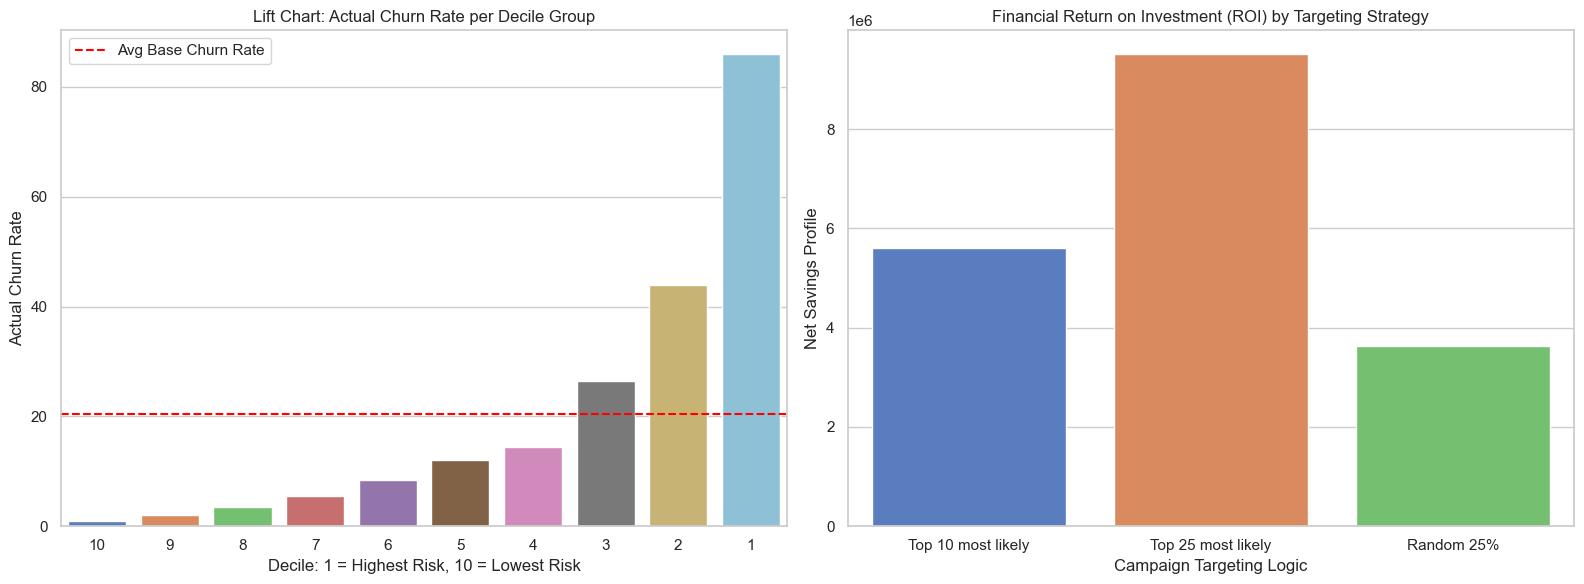

In [ ]:
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lift Chart (Churn Rate vs Decile)
sns.barplot(
    data=decile_summary, 
    x='decile', 
    y='churn_rate_%', 
    ax=axes[0], 
    palette='muted'
)

axes[0].axhline(
    y=y_test.mean()*100,
    color='red',
    linestyle='--',
    label='Avg Base Churn Rate'
)
axes[0].set_title('Lift Chart: Actual Churn Rate per Decile Group')
axes[0].set_xlabel('Decile: 1 = Highest Risk, 10 = Lowest Risk')
axes[0].set_ylabel('Actual Churn Rate')
axes[0].legend()

# Barplot
sns.barplot(
    data=roi_df, 
    x='Strategy', 
    y='Net ROI ($)', 
    ax=axes[1], 
    palette='muted'
)
axes[1].set_title('Financial Return on Investment (ROI) by Targeting Strategy')
axes[1].set_xlabel('Campaign Targeting Logic')
axes[1].set_ylabel('Net Savings Profile')

plt.tight_layout()
plt.show()

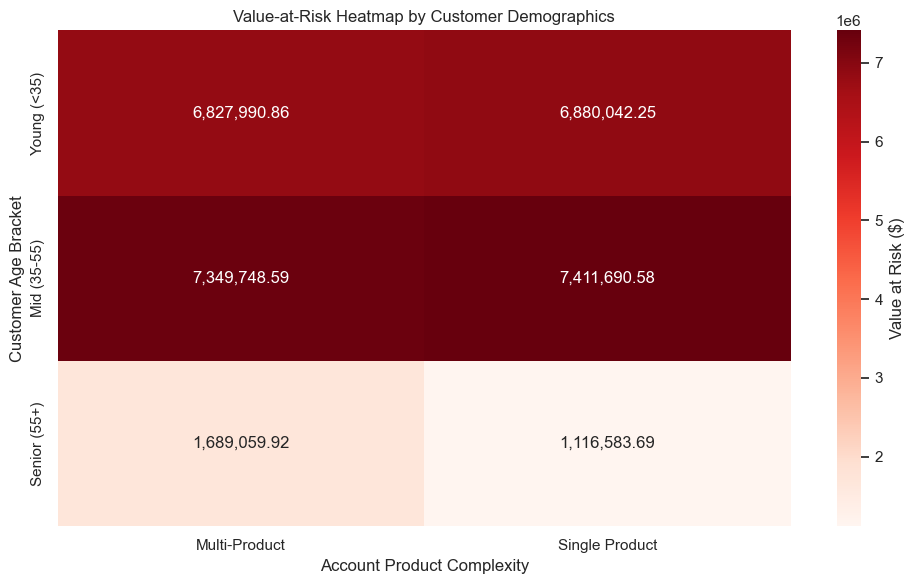

In [14]:
sim_df['age_group'] = pd.cut(
    X_test['age'].values, 
    bins=[0, 35, 55, np.inf],
    labels=['Young (<35)', 'Mid (35-55)', 'Senior (55+)']
)
sim_df['product_tier'] = np.where(
    X_test['products_number'].values > 1, 
    'Multi-Product', 
    'Single Product'
)

heatmap_data = sim_df.groupby(['age_group', 'product_tier'], observed=False).apply(
    lambda x: x['balance'].sum() * x['actual_churn'].mean(), include_groups=False
).unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=",.2f", cmap='Reds', cbar_kws={'label': 'Value at Risk ($)'})
plt.title('Value-at-Risk Heatmap by Customer Demographics')
plt.ylabel('Customer Age Bracket')
plt.xlabel('Account Product Complexity')
plt.tight_layout()
plt.show()